<a href="https://colab.research.google.com/github/Rija2005/--learn-javascript/blob/main/labtaskpractice.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Import the libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    accuracy_score,
    precision_score,
    recall_score,
    confusion_matrix
)

In [3]:
# Load the student dataset
df = pd.read_csv("student-mat.csv")
df.head()

,school;sex;age;address;famsize;Pstatus;Medu;Fedu;Mjob;Fjob;reason;guardian;traveltime;studytime;failures;schoolsup;famsup;paid;activities;nursery;higher;internet;romantic;famrel;freetime;goout;Dalc;Walc;health;absences;G1;G2;G3
0,"GP;""F"";18;""U"";""GT3"";""A"";4;4;""at_home"";""teacher..."
1,"GP;""F"";17;""U"";""GT3"";""T"";1;1;""at_home"";""other"";..."
2,"GP;""F"";15;""U"";""LE3"";""T"";1;1;""at_home"";""other"";..."
3,"GP;""F"";15;""U"";""GT3"";""T"";4;2;""health"";""services..."
4,"GP;""F"";16;""U"";""GT3"";""T"";3;3;""other"";""other"";""h..."


In [4]:
# Check the number of rows and columns
print("Shape:", df.shape)
print(df.columns)
# Check data types
print(df.dtypes)

Shape: (395, 1)
Index(['school;sex;age;address;famsize;Pstatus;Medu;Fedu;Mjob;Fjob;reason;guardian;traveltime;studytime;failures;schoolsup;famsup;paid;activities;nursery;higher;internet;romantic;famrel;freetime;goout;Dalc;Walc;health;absences;G1;G2;G3'], dtype='object')
school;sex;age;address;famsize;Pstatus;Medu;Fedu;Mjob;Fjob;reason;guardian;traveltime;studytime;failures;schoolsup;famsup;paid;activities;nursery;higher;internet;romantic;famrel;freetime;goout;Dalc;Walc;health;absences;G1;G2;G3    object
dtype: object


In [5]:
# Check missing values in every column
print(df.isnull().sum())

school;sex;age;address;famsize;Pstatus;Medu;Fedu;Mjob;Fjob;reason;guardian;traveltime;studytime;failures;schoolsup;famsup;paid;activities;nursery;higher;internet;romantic;famrel;freetime;goout;Dalc;Walc;health;absences;G1;G2;G3    0
dtype: int64


In [8]:
df = pd.read_csv("student-mat.csv", sep=";")
# Select the columns we need
df = df[["studytime", "absences", "G1", "G2", "G3"]]
# Show the data
df.head()

,studytime,absences,G1,G2,G3
0,2,6,5,6,6
1,2,4,5,5,6
2,2,10,7,8,10
3,3,2,15,14,15
4,2,4,6,10,10


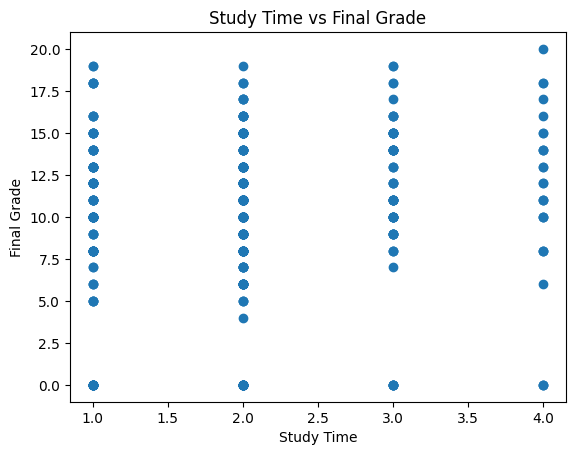

In [9]:
plt.scatter(df["studytime"], df["G3"])
plt.xlabel("Study Time")
plt.ylabel("Final Grade")
plt.title("Study Time vs Final Grade")
plt.show()

In [10]:
X = df[["studytime", "absences", "G1", "G2"]]
y = df["G3"]

In [11]:
# Split the data into training and testing parts
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)
print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (316, 4)
Testing data: (79, 4)


In [12]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [13]:
linear_model = LinearRegression()
# Train the model
linear_model.fit(X_train_scaled, y_train)

LinearRegression()

In [14]:
# Predict final marks
y_pred = linear_model.predict(X_test_scaled)
# Show some predictions
print(y_pred[:10])

[ 7.10303103 12.10922942  3.47955361  8.28177318  8.56270885 12.61066495
 18.81452156  6.84469902  6.98026635 12.52212142]


In [15]:
# Calculate evaluation metrics
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)
print("Mean Absolute Error:", mae)
print("Mean Squared Error:", mse)
print("Root Mean Squared Error:", rmse)
print("R2 Score:", r2)

Mean Absolute Error: 1.312574939624357
Mean Squared Error: 4.178975406386837
Root Mean Squared Error: 2.044254242110515
R2 Score: 0.7961977189442984


In [16]:
# Create a new column for pass/fail
df["pass"] = (df["G3"] >= 10).astype(int)
# Show the result
df[["G3", "pass"]].head(10)

,G3,pass
0,6,0
1,6,0
2,10,1
3,15,1
4,10,1
5,15,1
6,11,1
7,6,0
8,19,1
9,15,1


In [21]:
# Set the binary target variable 'pass' as y

# Split the data using the binary target variable for stratification
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=42,)
print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (316, 4)
Testing data: (79, 4)


In [22]:
# Scale the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [25]:
# Instantiate and train the Logistic Regression model
logistic_model = LogisticRegression()
logistic_model.fit(X_train_scaled, y_train)

# Make predictions
y_pred = logistic_model.predict(X_test_scaled)
print(y_pred[:10])

[10 13  8 10 10 12 18  9  0 11]


In [27]:
# Convert true values and predicted values to binary pass/fail (1 if >= 10, else 0)
y_test_binary = (y_test >= 10).astype(int)
y_pred_binary = (y_pred >= 10).astype(int)

# Calculate classification metrics using the binary targets
accuracy = accuracy_score(y_test_binary, y_pred_binary)
precision = precision_score(y_test_binary, y_pred_binary)
recall = recall_score(y_test_binary, y_pred_binary)

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)

Accuracy: 0.9113924050632911
Precision: 0.8947368421052632
Recall: 0.9807692307692307


First 5 rows:
   Age Attrition     BusinessTravel  DailyRate              Department  \
0   41       Yes      Travel_Rarely       1102                   Sales   
1   49        No  Travel_Frequently        279  Research & Development   
2   37       Yes      Travel_Rarely       1373  Research & Development   
3   33        No  Travel_Frequently       1392  Research & Development   
4   27        No      Travel_Rarely        591  Research & Development   

   DistanceFromHome  Education EducationField  EmployeeCount  EmployeeNumber  \
0                 1          2  Life Sciences              1               1   
1                 8          1  Life Sciences              1               2   
2                 2          2          Other              1               4   
3                 3          4  Life Sciences              1               5   
4                 2          1        Medical              1               7   

   ...  RelationshipSatisfaction StandardHours  StockOptionL

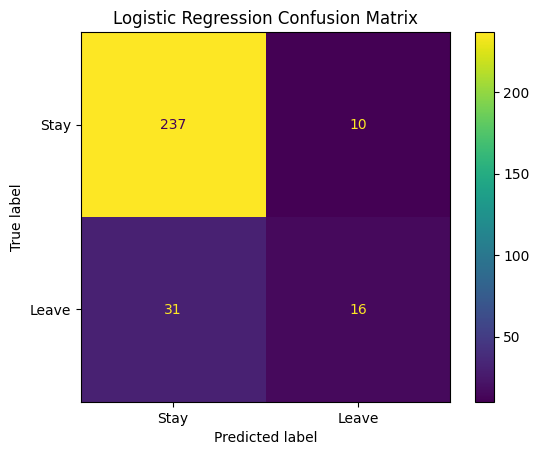

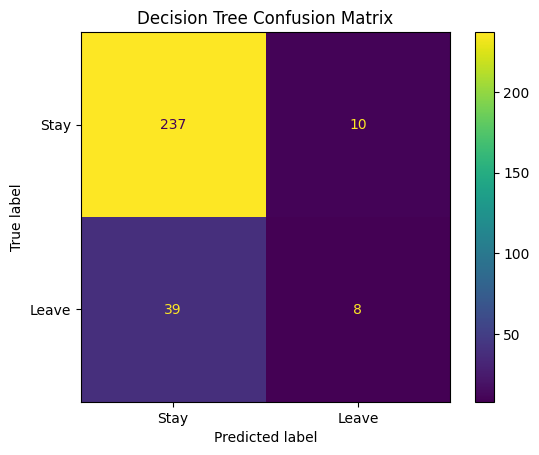


Top 10 Important Features:
TotalWorkingYears             0.227763
OverTime_Yes                  0.147191
DailyRate                     0.113395
MonthlyIncome                 0.108999
Age                           0.100578
MaritalStatus_Single          0.057004
JobRole_Research Scientist    0.049864
NumCompaniesWorked            0.042111
HourlyRate                    0.038135
YearsInCurrentRole            0.033556
dtype: float64


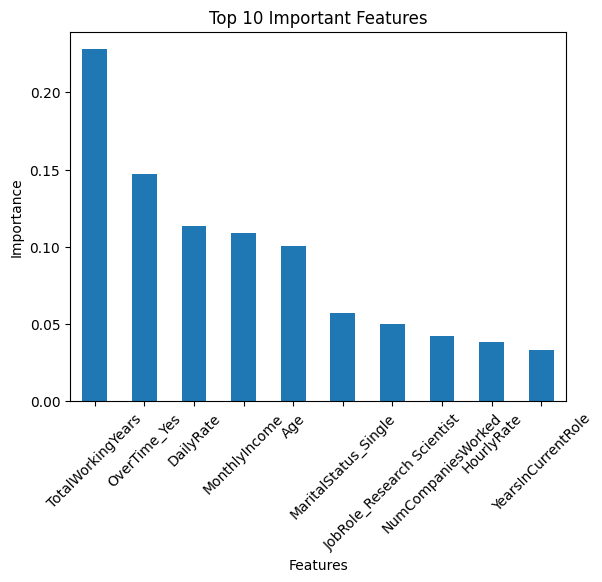


----- Model Comparison -----
Logistic Regression Accuracy: 0.8605442176870748
Logistic Regression F1 Score: 0.4383561643835616
Decision Tree Accuracy: 0.8333333333333334
Decision Tree F1 Score: 0.24615384615384617


In [28]:
# ============================================================
# Project Name: Employee Attrition Analyzer
# Roll No: YOUR_ROLL_NO
# ============================================================

# 1. Import libraries

import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, f1_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay


# ============================================================
# 2. Load Dataset
# ============================================================

data = pd.read_csv("WA_Fn-UseC_-HR-Employee-Attrition.csv")

print("First 5 rows:")
print(data.head())

print("\nDataset Information:")
print(data.info())

print("\nMissing Values:")
print(data.isnull().sum())


# ============================================================
# 3. Remove unnecessary columns
# ============================================================

# These columns do not help in prediction
data = data.drop([
    "EmployeeCount",
    "EmployeeNumber",
    "Over18",
    "StandardHours"
], axis=1)


# ============================================================
# 4. Convert Attrition into numbers
# ============================================================

# Yes = 1
# No = 0

data["Attrition"] = data["Attrition"].map({
    "Yes": 1,
    "No": 0
})


# ============================================================
# 5. Convert categorical columns into numbers
# ============================================================

data = pd.get_dummies(data, drop_first=True)


# ============================================================
# 6. Separate Features and Target
# ============================================================

X = data.drop("Attrition", axis=1)

y = data["Attrition"]


# ============================================================
# 7. Train-Test Split
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


# ============================================================
# 8. Feature Scaling
# ============================================================

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)


# ============================================================
# 9. Logistic Regression
# ============================================================

logistic_model = LogisticRegression(max_iter=1000)

logistic_model.fit(X_train_scaled, y_train)

logistic_prediction = logistic_model.predict(X_test_scaled)


# ============================================================
# 10. Decision Tree
# ============================================================

tree_model = DecisionTreeClassifier(
    max_depth=5,
    random_state=42
)

tree_model.fit(X_train, y_train)

tree_prediction = tree_model.predict(X_test)


# ============================================================
# 11. Evaluate Logistic Regression
# ============================================================

logistic_accuracy = accuracy_score(
    y_test,
    logistic_prediction
)

logistic_f1 = f1_score(
    y_test,
    logistic_prediction
)

print("\n----- Logistic Regression -----")

print("Accuracy:", logistic_accuracy)
print("F1 Score:", logistic_f1)


# ============================================================
# 12. Evaluate Decision Tree
# ============================================================

tree_accuracy = accuracy_score(
    y_test,
    tree_prediction
)

tree_f1 = f1_score(
    y_test,
    tree_prediction
)

print("\n----- Decision Tree -----")

print("Accuracy:", tree_accuracy)
print("F1 Score:", tree_f1)


# ============================================================
# 13. Confusion Matrix - Logistic Regression
# ============================================================

cm_logistic = confusion_matrix(
    y_test,
    logistic_prediction
)

display = ConfusionMatrixDisplay(
    confusion_matrix=cm_logistic,
    display_labels=["Stay", "Leave"]
)

display.plot()

plt.title("Logistic Regression Confusion Matrix")
plt.show()


# ============================================================
# 14. Confusion Matrix - Decision Tree
# ============================================================

cm_tree = confusion_matrix(
    y_test,
    tree_prediction
)

display = ConfusionMatrixDisplay(
    confusion_matrix=cm_tree,
    display_labels=["Stay", "Leave"]
)

display.plot()

plt.title("Decision Tree Confusion Matrix")
plt.show()


# ============================================================
# 15. Feature Importance
# ============================================================

importance = pd.Series(
    tree_model.feature_importances_,
    index=X.columns
)

importance = importance.sort_values(
    ascending=False
).head(10)

print("\nTop 10 Important Features:")
print(importance)


# ============================================================
# 16. Feature Importance Visualization
# ============================================================

importance.plot(kind="bar")

plt.title("Top 10 Important Features")
plt.xlabel("Features")
plt.ylabel("Importance")

plt.xticks(rotation=45)

plt.show()


# ============================================================
# 17. Model Comparison
# ============================================================

print("\n----- Model Comparison -----")

print("Logistic Regression Accuracy:", logistic_accuracy)
print("Logistic Regression F1 Score:", logistic_f1)

print("Decision Tree Accuracy:", tree_accuracy)
print("Decision Tree F1 Score:", tree_f1)

           id             date   price  bedrooms  bathrooms  sqft_living  \
0  7129300520  20141013T000000  221900         3       1.00         1180   
1  6414100192  20141209T000000  538000         3       2.25         2570   
2  5631500400  20150225T000000  180000         2       1.00          770   
3  2487200875  20141209T000000  604000         4       3.00         1960   
4  1954400510  20150218T000000  510000         3       2.00         1680   

   sqft_lot  floors  waterfront  view  ...  grade  sqft_above  sqft_basement  \
0      5650     1.0           0     0  ...      7        1180              0   
1      7242     2.0           0     0  ...      7        2170            400   
2     10000     1.0           0     0  ...      6         770              0   
3      5000     1.0           0     0  ...      7        1050            910   
4      8080     1.0           0     0  ...      8        1680              0   

   yr_built  yr_renovated  zipcode      lat     long  sqft_liv

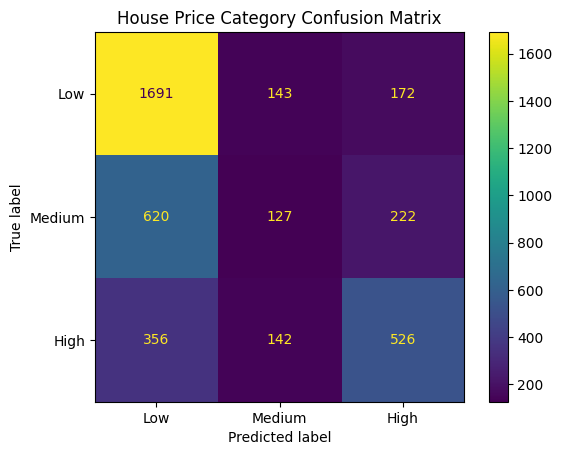

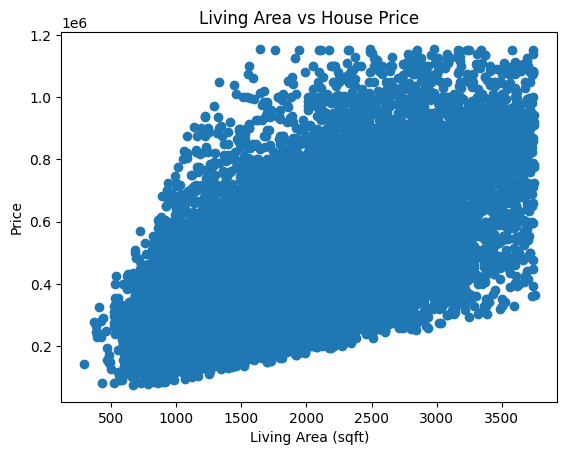

In [32]:
# ============================================================
# Project: House Price & Category Prediction
# Roll No: YOUR_ROLL_NO
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import r2_score, accuracy_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay


# ============================================================
# 1. Load Dataset
# ============================================================

data = pd.read_csv("house_data.csv")

print(data.head())

print("\nMissing Values:")
print(data.isnull().sum())


# ============================================================
# 2. Select useful columns
# ============================================================

data = data[["sqft_living", "bedrooms", "price"]]





# ============================================================
# 4. Remove outliers
# ============================================================

data = data[
    (data["sqft_living"] < data["sqft_living"].quantile(0.95)) &
    (data["price"] < data["price"].quantile(0.95))
]


# ============================================================
# 5. Create Price Categories
# ============================================================

median_price = data["price"].median()
high_price = data["price"].quantile(0.75)


def price_category(price):

    if price < median_price:
        return 0       # Low

    elif price < high_price:
        return 1       # Medium

    else:
        return 2       # High


data["category"] = data["price"].apply(price_category)


# ============================================================
# 6. Select input and output
# ============================================================

X = data[["sqft_living", "bedrooms"]]

y_price = data["price"]

y_category = data["category"]


# ============================================================
# 7. Train-Test Split for Linear Regression
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_price,
    test_size=0.2,
    random_state=42
)


# ============================================================
# 8. Feature Scaling
# ============================================================

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)


# ============================================================
# 9. Linear Regression
# ============================================================

linear_model = LinearRegression()

linear_model.fit(
    X_train_scaled,
    y_train
)

price_prediction = linear_model.predict(
    X_test_scaled
)


# R2 Score

r2 = r2_score(
    y_test,
    price_prediction
)

print("\n===== Linear Regression =====")
print("R2 Score:", r2)


# ============================================================
# 10. Random Forest Classification
# ============================================================

X_train2, X_test2, y_train2, y_test2 = train_test_split(
    X,
    y_category,
    test_size=0.2,
    random_state=42
)


random_forest = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

random_forest.fit(
    X_train2,
    y_train2
)


category_prediction = random_forest.predict(
    X_test2
)


# Accuracy

accuracy = accuracy_score(
    y_test2,
    category_prediction
)

print("\n===== Random Forest =====")
print("Accuracy:", accuracy)


# ============================================================
# 11. Confusion Matrix
# ============================================================

cm = confusion_matrix(
    y_test2,
    category_prediction
)

display = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Low", "Medium", "High"]
)

display.plot()

plt.title("House Price Category Confusion Matrix")

plt.show()


# ============================================================
# 12. Visualization
# ============================================================

plt.scatter(
    data["sqft_living"],
    data["price"]
)

plt.xlabel("Living Area (sqft)")

plt.ylabel("Price")

plt.title("Living Area vs House Price")

plt.show()

   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  

Missing Values:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

SV

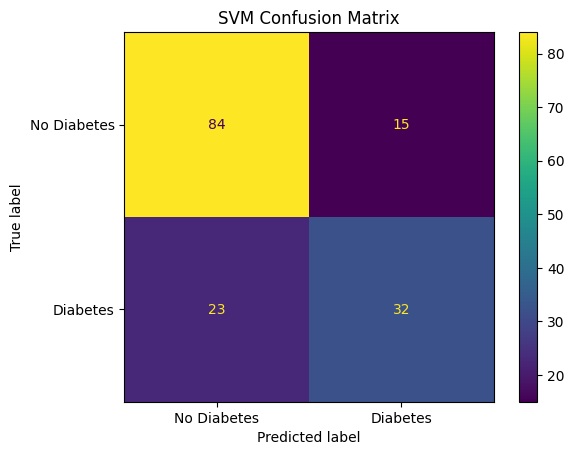

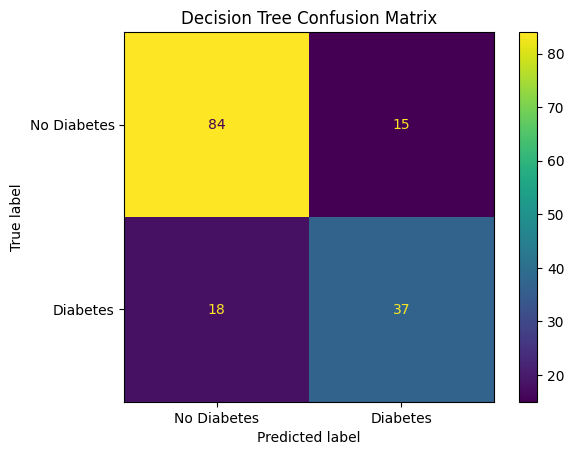


MODEL COMPARISON
SVM Accuracy: 0.7532467532467533
Decision Tree Accuracy: 0.7857142857142857


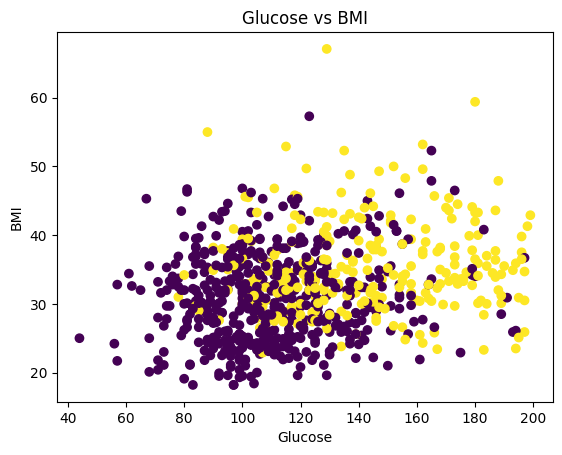

In [30]:
# ============================================================
# Project: Health Risk Classification
# Roll No: YOUR_ROLL_NO
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay


# 1. Load Dataset
data = pd.read_csv("diabetes.csv")

print(data.head())

print("\nMissing Values:")
print(data.isnull().sum())


# 2. Handle missing values
# In this dataset, 0 can represent missing values
columns = [
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI"
]

for column in columns:
    data[column] = data[column].replace(0, data[column].median())


# 3. Separate input and output

X = data.drop("Outcome", axis=1)

y = data["Outcome"]


# 4. Train-test split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)


# 5. Normalize / Scale data

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)


# ============================================================
# MODEL 1: SVM
# ============================================================

svm_model = SVC()

svm_model.fit(
    X_train_scaled,
    y_train
)

svm_prediction = svm_model.predict(
    X_test_scaled
)

svm_accuracy = accuracy_score(
    y_test,
    svm_prediction
)

print("\nSVM")
print("Accuracy:", svm_accuracy)


# ============================================================
# MODEL 2: Decision Tree
# ============================================================

tree_model = DecisionTreeClassifier(
    max_depth=5,
    random_state=42
)

tree_model.fit(
    X_train,
    y_train
)

tree_prediction = tree_model.predict(
    X_test
)

tree_accuracy = accuracy_score(
    y_test,
    tree_prediction
)

print("\nDecision Tree")
print("Accuracy:", tree_accuracy)


# ============================================================
# Confusion Matrix - SVM
# ============================================================

cm = confusion_matrix(
    y_test,
    svm_prediction
)

display = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No Diabetes", "Diabetes"]
)

display.plot()

plt.title("SVM Confusion Matrix")
plt.show()


# ============================================================
# Confusion Matrix - Decision Tree
# ============================================================

cm2 = confusion_matrix(
    y_test,
    tree_prediction
)

display2 = ConfusionMatrixDisplay(
    confusion_matrix=cm2,
    display_labels=["No Diabetes", "Diabetes"]
)

display2.plot()

plt.title("Decision Tree Confusion Matrix")
plt.show()


# ============================================================
# Model Comparison
# ============================================================

print("\n==============================")
print("MODEL COMPARISON")
print("==============================")

print("SVM Accuracy:", svm_accuracy)

print("Decision Tree Accuracy:", tree_accuracy)


# ============================================================
# Simple Visualization
# ============================================================

plt.scatter(
    data["Glucose"],
    data["BMI"],
    c=data["Outcome"]
)

plt.xlabel("Glucose")
plt.ylabel("BMI")
plt.title("Glucose vs BMI")

plt.show()